Saving insurance - insurance.csv to insurance - insurance.csv
Dataset Loaded Successfully
   age  sex     bmi  children  smoker  region      charges  insuranceclaim
0   19    0  27.900         0       1       3  16884.92400               1
1   18    1  33.770         1       0       2   1725.55230               1
2   28    1  33.000         3       0       2   4449.46200               0
3   33    1  22.705         0       0       1  21984.47061               0
4   32    1  28.880         0       0       1   3866.85520               1

Shape after removing NULL values:
(99, 8)

Mean value used: 14701.392996969698
Median value used: 10797.3362
Mode value used: 7281.5056

Age values > 60 replaced with 50

Number of duplicate rows: 1
Shape after removing duplicates: (100, 8)

Correlation Matrix:
                     age       sex       bmi  children    smoker    region  \
age             1.000000 -0.158964 -0.064789 -0.060234 -0.080577 -0.132087   
sex            -0.158964  1.000000 -0.054

/tmp/ipykernel_3551/483913565.py:30: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_mean['charges'].fillna(df_mean['charges'].mean(), inplace=True)
/tmp/ipykernel_3551/483913565.py:34: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, in

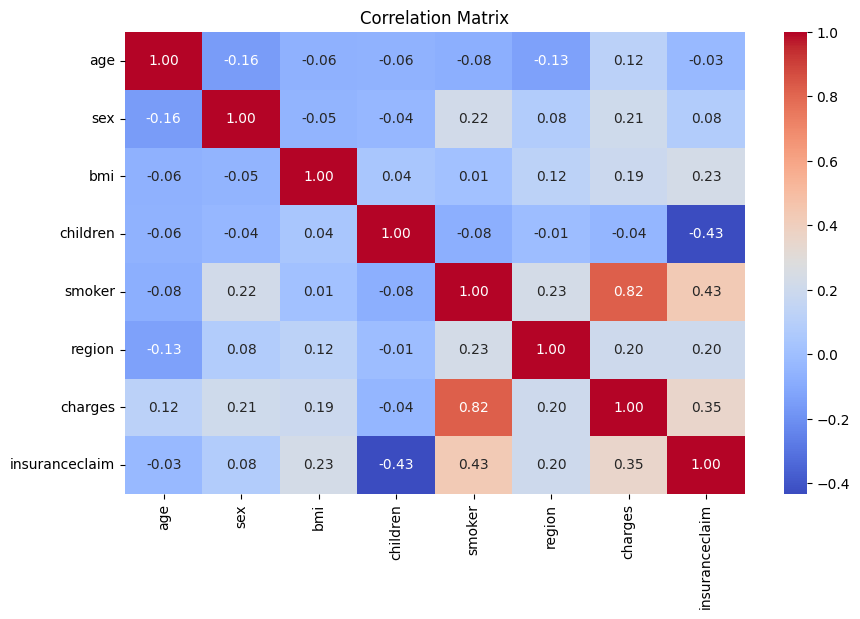

In [1]:
# Import libraries
import pandas as pd
import numpy as np
from google.colab import files

# Upload the dataset
uploaded = files.upload()

# Read the uploaded CSV file
df = pd.read_csv(next(iter(uploaded)))

print("Dataset Loaded Successfully")
print(df.head())

# =====================================================
# 1. Remove rows having NULL values
# =====================================================

df_no_null = df.dropna()

print("\nShape after removing NULL values:")
print(df_no_null.shape)

# =====================================================
# 2. Fill Empty cells in 'charges' column
# =====================================================

# a) Mean
df_mean = df.copy()
df_mean['charges'].fillna(df_mean['charges'].mean(), inplace=True)

# b) Median
df_median = df.copy()
df_median['charges'].fillna(df_median['charges'].median(), inplace=True)

# c) Mode
df_mode = df.copy()
df_mode['charges'].fillna(df_mode['charges'].mode()[0], inplace=True)

print("\nMean value used:", df['charges'].mean())
print("Median value used:", df['charges'].median())
print("Mode value used:", df['charges'].mode()[0])

# =====================================================
# 3. Replace values greater than 60 in 'age' column with 50
# =====================================================

df_age = df.copy()
df_age.loc[df_age['age'] > 60, 'age'] = 50

print("\nAge values > 60 replaced with 50")

# =====================================================
# 4. Find and remove duplicates
# =====================================================

duplicate_count = df.duplicated().sum()

print("\nNumber of duplicate rows:", duplicate_count)

df_no_duplicates = df.drop_duplicates()

print("Shape after removing duplicates:", df_no_duplicates.shape)

# =====================================================
# 5. Correlation between data
# =====================================================

# Convert categorical columns to numeric
df_corr = df.copy()

for col in df_corr.select_dtypes(include='object').columns:
    df_corr[col] = pd.factorize(df_corr[col])[0]

correlation_matrix = df_corr.corr()

print("\nCorrelation Matrix:")
print(correlation_matrix)

# Heatmap
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(correlation_matrix,
            annot=True,
            cmap='coolwarm',
            fmt='.2f')

plt.title("Correlation Matrix")
plt.show()